#### Classification problems in ML 


- understanding the features by looking at their distribution 



- preparing the data (eventually feature engineering)



- fitting the model and parameter tuning 



- crossvalidation, bias and variance



- performance measures for classification problems  

In [122]:
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt

In [123]:
data = pd.read_csv("dati/diabetes.csv")

In [124]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [125]:
data.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

#### Analysis and visualization  

In [126]:
mat_corr = data.corr()

<AxesSubplot:>

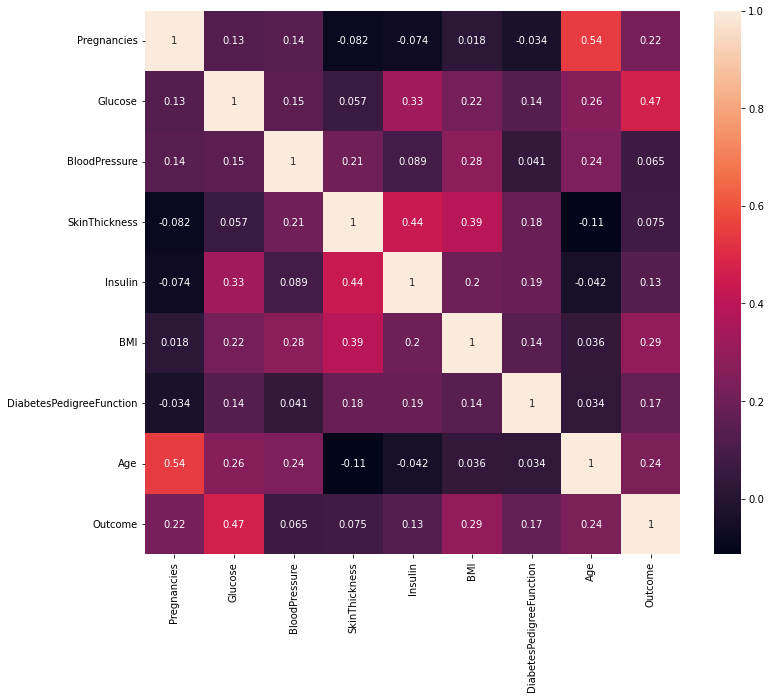

In [127]:
plt.figure(figsize = (12,10))
sb.heatmap(mat_corr, annot = True)

In [128]:
positive = data[data["Outcome"] == 1]
negative = data[data["Outcome"] == 0]

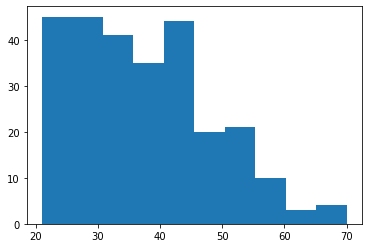

In [177]:
plt.hist(positive["Age"])
plt.show()

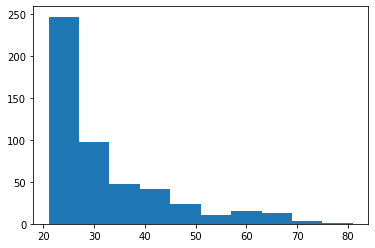

In [178]:
plt.hist(negative["Age"])
plt.show()

#### Prepare data for classification model

In [131]:
X = data.iloc[:, 0:8].values
y = data.iloc[:, -1].values

In [132]:
X

array([[  6.   , 148.   ,  72.   , ...,  33.6  ,   0.627,  50.   ],
       [  1.   ,  85.   ,  66.   , ...,  26.6  ,   0.351,  31.   ],
       [  8.   , 183.   ,  64.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [  5.   , 121.   ,  72.   , ...,  26.2  ,   0.245,  30.   ],
       [  1.   , 126.   ,  60.   , ...,  30.1  ,   0.349,  47.   ],
       [  1.   ,  93.   ,  70.   , ...,  30.4  ,   0.315,  23.   ]])

In [133]:
from sklearn.model_selection import train_test_split

In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [135]:
X_test.shape

(154, 8)

In [136]:
from sklearn.neighbors import KNeighborsClassifier

In [155]:
knn = KNeighborsClassifier(n_neighbors = 16)

In [156]:
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=16)

In [157]:
yhat = knn.predict(X_test)

In [158]:
yhat[:10]

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [159]:
import numpy as np
xi = np.array([2, 189, 66, 23, 94, 30.1, 0.167, 51]).reshape(1 , -1)
knn.predict(xi)

array([1])

In [179]:
y_test[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [180]:
from sklearn import metrics

In [181]:
acc_knn = metrics.accuracy_score(yhat, y_test)

In [183]:
acc_knn

0.7857142857142857

### The problem with the accuracy

- How good is a 99% accuracy for a classification problem?

### Other metrics for evaluating a classification model. 

- Precision 

- Recall 

- f1 score

In [185]:
print(metrics.classification_report(yhat, y_test))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85       118
           1       0.53      0.81      0.64        36

    accuracy                           0.79       154
   macro avg       0.73      0.79      0.74       154
weighted avg       0.84      0.79      0.80       154



In [170]:
metrics.precision_score(yhat, y_test)

0.5272727272727272

In [171]:
# compute the precision by using TP and FP
29/(29 + 26)

0.5272727272727272

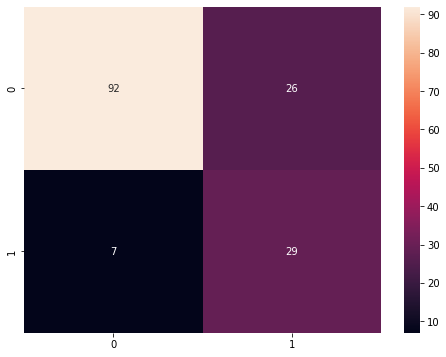

In [176]:
plt.figure(figsize = (8, 6))
sb.heatmap(metrics.confusion_matrix(yhat, y_test), annot=True)
plt.show()

#### K-Fold Crossvalidation, bias and variance  

In [173]:
from sklearn.model_selection import cross_val_score

In [174]:
score = cross_val_score(knn, X, y,  cv=5, scoring='precision')

In [152]:
score


array([0.62162162, 0.63636364, 0.76190476, 0.71052632, 0.65714286])

In [153]:
score.mean()

0.6775118385644701

In [154]:
score.std()

0.05185346182232007

In [3]:
l = ["alket", "alket", "sasha", "sasha", "sasha", "john"]
d = {}
for i in l: 
    print(i)
    
    if i not in d: 
        d[i] = 1
    else: 
        count = d[i]
        count = count +1
        d[i] = count

alket
alket
sasha
sasha
sasha
john


In [4]:
d

{'alket': 2, 'sasha': 3, 'john': 1}

In [5]:
from collections import Counter

In [6]:
count = Counter(l)

In [7]:
count

Counter({'alket': 2, 'sasha': 3, 'john': 1})